# Preprocesamiento de Datos - Telco Customer Churn

**Objetivo:** A partir de los hallazgos del EDA (`01_EDA_Telco_Churn.ipynb`), aplicar de forma sistemática los pasos de limpieza, codificación y escalado necesarios para dejar los datos listos para el modelado, evitando *data leakage* entre `train` y `test`.

## 1. Importación de librerías

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## 2. Carga de datos y variable objetivo

In [4]:
df = pd.read_csv(r'C:\Users\laure\Documents\Company_Bankruptcy_Prediction\data\data_2.csv')
df.columns = df.columns.str.strip()

TARGET = 'Churn'
if TARGET not in df.columns:
    posibles_target = [col for col in df.columns if 'churn' in col.lower()]
    if posibles_target:
        TARGET = posibles_target[0]

print(f"Dimensiones del dataset completo: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del dataset completo: 7043 filas x 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. División train / test

Se replica la misma partición estratificada usada en el EDA (misma `random_state`), para mantener consistencia entre ambos notebooks.

In [5]:
X = df.drop(columns=[TARGET, 'customerID'])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Observaciones en train: {len(X_train)}")
print(f"Observaciones en test:  {len(X_test)}")

Observaciones en train: 5634
Observaciones en test:  1409


## 4. Pasos de preprocesamiento definidos a partir del EDA

1. **Manejo del target:** convertir `Churn` de 'Yes'/'No' a 1/0.
2. **Manejo de `TotalCharges`:** convertir a numérico e imputar los nulos (clientes nuevos con `tenure = 0`) con **0**.
3. **Ingeniería de características:**
   - Colapsar las categorías redundantes "No internet service" / "No phone service" (el EDA confirmó 0 discrepancias con `InternetService`/`PhoneService`: es información 100% duplicada).
   - Crear `AvgChargePerMonth` (cargo promedio histórico) para aprovechar la relación `tenure`–`TotalCharges` (r = 0.83) sin eliminar ninguna de las dos variables originales.
   - Conservar `gender` y `PhoneService` aunque el EDA no encontró asociación bivariada significativa con Churn: un test bivariado no ve interacciones con otras variables, así que se deja que el propio modelo confirme (o descarte) su aporte con toda la información disponible.
4. **Codificación de variables categóricas:**
   - Variables nominales (más de 2 categorías, incluyendo binarias tipo Yes/No): One-Hot Encoding (OHE).
5. **Escalado de variables numéricas:** `tenure`, `MonthlyCharges`, `TotalCharges` y `AvgChargePerMonth` se estandarizan con `StandardScaler`.

Todas las decisiones (parámetros de imputación, escalado y codificación) se **aprenden únicamente de `train`** y luego se aplican a `test`, para evitar *data leakage*.

### 4.1 Manejo del target

In [6]:
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

print(y_train.value_counts(normalize=True))

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


### 4.2 Manejo de `TotalCharges`

In [7]:
# Convertir a numérico, forzando errores (espacios en blanco) a NaN
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce')
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')

print("Nulos en TotalCharges (train) antes de imputar:", X_train['TotalCharges'].isnull().sum())
print("Nulos en TotalCharges (test) antes de imputar:", X_test['TotalCharges'].isnull().sum())

# Imputar con 0 (clientes nuevos, tenure = 0), decisión basada en el hallazgo del EDA
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(0)
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(0)

print("Nulos en TotalCharges (train) después de imputar:", X_train['TotalCharges'].isnull().sum())
print("Nulos en TotalCharges (test) después de imputar:", X_test['TotalCharges'].isnull().sum())

Nulos en TotalCharges (train) antes de imputar: 8
Nulos en TotalCharges (test) antes de imputar: 3
Nulos en TotalCharges (train) después de imputar: 0
Nulos en TotalCharges (test) después de imputar: 0


### 4.3 Ingeniería de características a partir del EDA

**a) Colapsar categorías redundantes.** El EDA confirmó (sección de consistencia, "0 discrepancias") que "No internet service" y "No phone service" son información 100% duplicada con `InternetService`/`PhoneService`. No hay trade-off real: colapsarlas solo reduce dimensionalidad del One-Hot Encoding sin perder señal.

In [8]:
# Colapsar categorías redundantes detectadas en el EDA:
# "No internet service" y "No phone service" ya están implícitas en
# InternetService y PhoneService respectivamente — mantenerlas duplica esa información
cols_no_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                     'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in cols_no_internet:
    X_train[col] = X_train[col].replace('No internet service', 'No')
    X_test[col] = X_test[col].replace('No internet service', 'No')

X_train['MultipleLines'] = X_train['MultipleLines'].replace('No phone service', 'No')
X_test['MultipleLines'] = X_test['MultipleLines'].replace('No phone service', 'No')

print("Categorías únicas tras colapsar (ejemplo, OnlineSecurity):", X_train['OnlineSecurity'].unique())
print("Categorías únicas tras colapsar (MultipleLines):", X_train['MultipleLines'].unique())

Categorías únicas tras colapsar (ejemplo, OnlineSecurity): ['No' 'Yes']
Categorías únicas tras colapsar (MultipleLines): ['No' 'Yes']


**b) `tenure` vs `TotalCharges` (r = 0.83): variable derivada, no eliminación.** El EDA dejó esta correlación como un punto a resolver. La decisión más sólida es **no borrar ninguna de las dos originales**:

- Con Regresión Logística (regularización L2 por defecto en scikit-learn), la multicolinealidad moderada no rompe el modelo: el peso se reparte entre las variables correlacionadas. El problema real de la multicolinealidad aparece al interpretar coeficientes individuales, no al predecir.
- Eliminar una variable "a mano" tira información real: dos clientes con la misma antigüedad pueden tener `TotalCharges` distintos si pagaron planes diferentes — esa diferencia es señal, no ruido.
- Si más adelante se prueban modelos de árboles (Random Forest, Gradient Boosting), la multicolinealidad casi no los afecta, así que optimizar esto solo para el modelo lineal sería trabajo desperdiciado.

En su lugar, se agrega `AvgChargePerMonth` (cargo promedio histórico) como variable adicional, dejando que el modelo decida cuánto peso darle a cada una.

> **Cuidado con `tenure = 0`:** para esos clientes, `TotalCharges` ya se imputó en 0 (sección 4.2), así que `TotalCharges / tenure` daría 0, sugiriendo falsamente "no paga nada". En realidad sí tienen una tarifa mensual (`MonthlyCharges`), solo que aún no la han acumulado. Se usa `MonthlyCharges` como proxy para esos casos en vez de dividir directamente.
>
> **Honestidad sobre esta variable:** una vez corregida, `AvgChargePerMonth` termina siendo muy similar a `MonthlyCharges` para la mayoría de los clientes (porque `TotalCharges ≈ tenure × MonthlyCharges` cuando no hay cambios de plan). Su aporte real está en los casos donde diverge — clientes que cambiaron de plan con el tiempo. Es una variable barata de probar, no una solución mágica a la colinealidad; su utilidad se valida en la etapa de modelado, no se asume aquí.

In [9]:
# Cargo promedio histórico: relación entre lo acumulado y la antigüedad.
# Se agrega como variable adicional, sin eliminar tenure ni TotalCharges.
# Para tenure = 0, TotalCharges ya fue imputado a 0, por lo que TotalCharges/tenure
# daría 0 (sugiriendo "no paga nada"), lo cual es falso: sí tiene una tarifa mensual,
# solo que aún no la ha acumulado. Se usa MonthlyCharges como proxy en esos casos.
X_train['AvgChargePerMonth'] = np.where(
    X_train['tenure'] > 0,
    X_train['TotalCharges'] / X_train['tenure'],
    X_train['MonthlyCharges']
)
X_test['AvgChargePerMonth'] = np.where(
    X_test['tenure'] > 0,
    X_test['TotalCharges'] / X_test['tenure'],
    X_test['MonthlyCharges']
)

X_train[['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargePerMonth']].describe()

,tenure,MonthlyCharges,TotalCharges,AvgChargePerMonth
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,32.485091,64.929961,2299.334682,64.938144
std,24.568744,30.138105,2279.204278,30.224872
min,0.000000,18.400000,0.000000,13.828571
25%,9.000000,35.662500,402.975000,36.045516
50%,29.000000,70.500000,1394.925000,70.588666
75%,55.000000,90.000000,3835.825000,90.464446
max,72.000000,118.750000,8684.800000,121.400000


**c) `gender` y `PhoneService`: se conservan.** El EDA encontró que no tienen asociación bivariada significativa con Churn (tras corrección de Holm). Aun así, se mantienen en el pipeline, pero por una razón más simple y defendible que "el modelo puede captar interacciones ocultas":

- **Matiz importante:** una Regresión Logística *sin términos de interacción explícitos* no descubre por sí sola una interacción como `gender × SeniorCitizen` — ese argumento aplica más a modelos de árboles (Random Forest, Gradient Boosting) que sí pueden capturar ese tipo de patrones automáticamente. No es la razón principal para mantenerlas aquí.
- La razón real es más simple: son solo 2 variables de 15+, el costo de dejarlas es mínimo, y eliminarlas *a priori* con base en un test univariado es una práctica metodológicamente débil (pre-selección ciega de variables), independientemente de si el modelo capta o no interacciones.
- La evidencia final debe salir del propio modelo: si el coeficiente de `gender` en la regresión logística resulta cercano a 0, eso **confirma empíricamente** el hallazgo del EDA — es mejor evidencia para las conclusiones que haberlas eliminado de antemano por suposición.

Por eso no se eliminan aquí: se dejan en el pipeline y su aporte (o falta de él) se revisa con los coeficientes del modelo en la etapa de evaluación.

### 4.4 Definición de columnas por tipo

In [10]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'AvgChargePerMonth']
categorical_features = [col for col in X_train.columns if col not in numeric_features]

print(f"Numéricas ({len(numeric_features)}): {numeric_features}")
print(f"Categóricas ({len(categorical_features)}): {categorical_features}")

Numéricas (5): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'AvgChargePerMonth']
Categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 4.5 Construcción del ColumnTransformer

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

> **Nota:** `SeniorCitizen` ya es numérica (0/1) y se incluye en `numeric_features`; el `StandardScaler` no le hará daño (queda en una escala similar a las otras variables binarias tras la transformación) y simplifica el pipeline.

## 5. Aplicación del preprocesamiento

In [12]:
# Ajustar SOLO con train
X_train_processed = preprocessor.fit_transform(X_train)

# Transformar test (nunca ajustar de nuevo)
X_test_processed = preprocessor.transform(X_test)

print(f"Dimensiones de X_train_processed: {X_train_processed.shape}")
print(f"Dimensiones de X_test_processed: {X_test_processed.shape}")

Dimensiones de X_train_processed: (5634, 24)
Dimensiones de X_test_processed: (1409, 24)


### 5.1 Recuperar nombres de columnas resultantes (opcional, útil para interpretabilidad)

In [13]:
feature_names = preprocessor.get_feature_names_out()
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

X_train_processed_df.head()

,num__tenure,num__MonthlyCharges,num__TotalCharges,num__SeniorCitizen,num__AvgChargePerMonth,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_Yes,...,cat__DeviceProtection_Yes,cat__TechSupport_Yes,cat__StreamingTV_Yes,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
3738,0.102371,-0.521976,-0.262257,-0.441773,-0.539986,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,-0.711743,0.337478,-0.503635,-0.441773,0.391496,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,-0.793155,-0.809013,-0.749883,-0.441773,-0.646102,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3867,-0.263980,0.284384,-0.172722,-0.441773,0.276552,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
3810,-1.281624,-0.676279,-0.989374,-0.441773,-0.674608,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 6. Guardar los conjuntos procesados (opcional)

In [14]:
X_train_processed_df.to_csv('X_train_processed.csv', index=False)
X_test_processed_df.to_csv('X_test_processed.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Archivos guardados: X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv")

Archivos guardados: X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv


## 7. Prueba rápida con Regresión Logística

Antes de pasar a un modelado más elaborado, entrenamos una **Regresión Logística** como modelo base (*baseline*) sobre los datos ya preprocesados. Esto da un primer score de referencia contra el cual comparar modelos más complejos (Random Forest, Gradient Boosting, etc.).

Dado el desbalance de clases detectado en el EDA (~73% No Churn / ~27% Churn), usamos `class_weight='balanced'` y evaluamos con varias métricas además de la exactitud (Accuracy), ya que esta última puede ser engañosa en problemas desbalanceados.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

log_reg.fit(X_train_processed, y_train)

y_pred = log_reg.predict(X_test_processed)
y_proba = log_reg.predict_proba(X_test_processed)[:, 1]

### 7.1 Score general (Accuracy) y métricas clave

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy (score):  {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1-Score:          {f1:.4f}")
print(f"AUC-ROC:           {auc:.4f}")

print("\nEl método .score() de sklearn equivale a la Accuracy:")
print(f"log_reg.score(X_test_processed, y_test) = {log_reg.score(X_test_processed, y_test):.4f}")

Accuracy (score):  0.7388
Precision:         0.5052
Recall:            0.7861
F1-Score:          0.6151
AUC-ROC:           0.8419

El método .score() de sklearn equivale a la Accuracy:
log_reg.score(X_test_processed, y_test) = 0.7388


### 7.2 Matriz de confusión y reporte de clasificación

In [17]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión (filas: real, columnas: predicho):")
print(cm)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Matriz de confusión (filas: real, columnas: predicho):
[[747 288]
 [ 80 294]]

Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



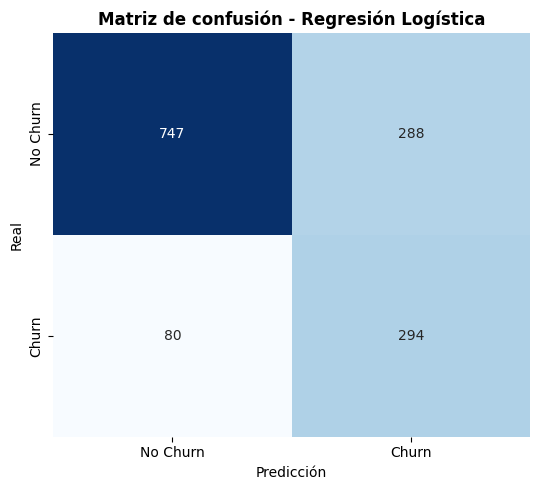

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'], ax=ax
)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión - Regresión Logística', fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Curva ROC

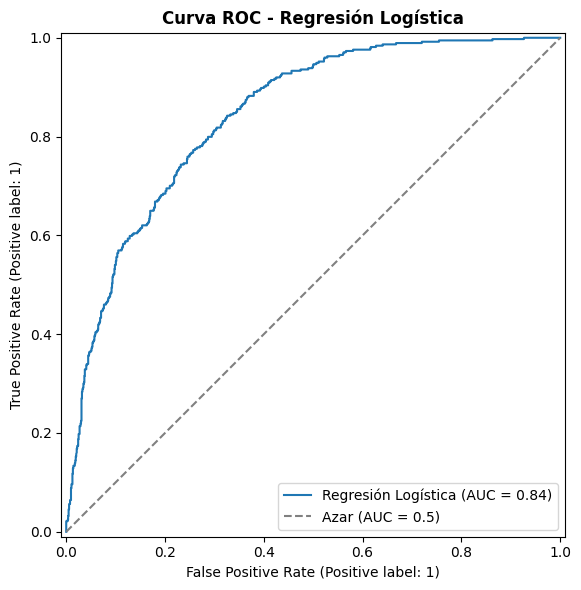

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='Regresión Logística')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC = 0.5)')
ax.set_title('Curva ROC - Regresión Logística', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7.4 Interpretación del resultado

- El **Accuracy** (score por defecto de sklearn) da una primera idea del desempeño general, pero al haber desbalance de clases (~27% Churn) puede sobreestimar la calidad del modelo si este favorece a la clase mayoritaria.
- El **Recall** de la clase Churn es especialmente importante en este problema de negocio: interesa detectar la mayor cantidad posible de clientes que realmente van a abandonar, aunque eso implique sacrificar algo de Precisión.
- El **AUC-ROC** resume la capacidad del modelo para separar ambas clases independientemente del umbral de decisión, y es más robusta que el Accuracy en este contexto.
- Este resultado de Regresión Logística sirve como **línea base** para comparar contra Random Forest, Gradient Boosting u otros algoritmos más adelante.

### 7.5 Cerrando el punto pendiente del EDA: ¿aportan `gender` y `PhoneService`?

En la sección 4.3 se decidió mantener `gender` y `PhoneService` pese a que el EDA no encontró asociación bivariada significativa con Churn, dejando que el propio modelo lo confirmara. Se revisan aquí sus coeficientes (ya estandarizados por el `StandardScaler` para las numéricas y codificados con OHE para las categóricas, por lo que la magnitud es comparable entre variables).

In [20]:
coeficientes = pd.Series(log_reg.coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False)

print("Todos los coeficientes ordenados por magnitud absoluta:")
print(coeficientes)

print("\nCoeficientes específicos de gender y PhoneService:")
cols_revisar = [c for c in feature_names if 'gender' in c or 'PhoneService' in c]
print(coeficientes[cols_revisar])

Todos los coeficientes ordenados por magnitud absoluta:
cat__Contract_Two year                       -1.414771
num__tenure                                  -1.140778
cat__InternetService_No                      -1.095142
cat__InternetService_Fiber optic              1.058314
cat__Contract_One year                       -0.721303
num__TotalCharges                             0.468794
cat__PaymentMethod_Electronic check           0.401170
cat__OnlineSecurity_Yes                      -0.363730
cat__StreamingMovies_Yes                      0.358041
cat__PaperlessBilling_Yes                     0.338012
cat__StreamingTV_Yes                          0.331868
num__MonthlyCharges                          -0.309501
cat__TechSupport_Yes                         -0.298389
cat__MultipleLines_Yes                        0.294034
cat__PhoneService_Yes                        -0.288930
cat__Dependents_Yes                          -0.227373
cat__OnlineBackup_Yes                        -0.104842
num__Seni

> Si estos coeficientes están entre los más cercanos a 0 (comparados con variables como `Contract` o `InternetService`), eso **confirma empíricamente**, ya con el modelo multivariado y no solo con el test bivariado del EDA, que `gender` y `PhoneService` aportan poco a esta Regresión Logística. Es una conclusión más sólida para el informe que haberlas eliminado de antemano por sospecha.

## 8. Resumen y próximos pasos

- El target se transformó a binario (0/1).
- `TotalCharges` se convirtió a numérico y sus nulos (clientes nuevos, `tenure = 0`) se imputaron con 0, usando una lógica derivada del EDA y aplicada de forma consistente a `train` y `test`.
- Se resolvieron los 3 hallazgos pendientes del EDA:
  - Se colapsaron las categorías redundantes ("No internet service" / "No phone service"), sin pérdida de señal.
  - Se agregó `AvgChargePerMonth` para complementar la relación `tenure`/`TotalCharges` (r = 0.83), sin eliminar ninguna de las dos originales, y corrigiendo el caso `tenure = 0` con `MonthlyCharges` como proxy.
  - Se conservaron `gender` y `PhoneService` en vez de eliminarlas a priori; su aporte real se confirmó revisando los coeficientes del modelo (sección 7.5), en vez de decidirlo solo con el test bivariado del EDA.
- Las variables numéricas se estandarizaron y las categóricas se codificaron con One-Hot Encoding, ajustando el transformador únicamente sobre `train`.
- Se entrenó y evaluó una **Regresión Logística** como modelo base, obteniendo su score (Accuracy) y métricas complementarias (Precision, Recall, F1, AUC-ROC) dado el desbalance de clases observado en el EDA.
- Los conjuntos `X_train_processed` / `X_test_processed` y `y_train` / `y_test` quedan listos para probar modelos adicionales (Random Forest, Gradient Boosting, etc.) y comparar su desempeño contra esta línea base.